# Semana 3 – Actividad 2: Backpropagation y Funciones de Activación

**Curso:** Deep Learning - Conceptos (601539)  
**Objetivo:** Implementar y validar el aprendizaje de redes neuronales mediante **backpropagation** y **funciones de activación** (sigmoide, ReLU) en clasificación binaria.

**Evidencia:** Tres modelos (perceptrón, una capa, multicapa) con backpropagation correcto, funciones de activación integradas, dataset de clasificación binaria y métricas claras.

In [ ]:
# Instalar dependencias (ejecutar solo si falta matplotlib, numpy o scikit-learn)
# En Google Colab suelen estar instaladas; en local puede ser necesario
%pip install numpy matplotlib scikit-learn -q

## 1. Dataset de clasificación binaria

Usamos `make_classification` de sklearn para generar datos binarios. Las etiquetas son 0 y 1.

Instalado: matplotlib. Ejecuta esta celda de nuevo.
Instalado: scikit-learn. Ejecuta esta celda de nuevo.
Forma X_train: (400, 2)  | y_train: (400, 1)
Clases: [0 1]


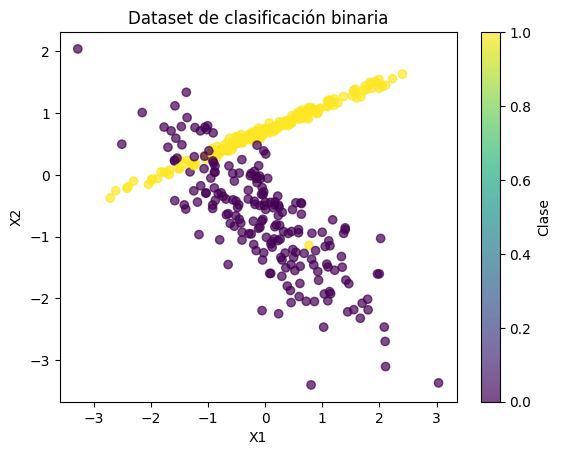

In [1]:
# Instalar dependencias si faltan
import subprocess, sys
for pkg in ["numpy", "matplotlib", "scikit-learn"]:
    try:
        __import__(pkg)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"Instalado: {pkg}. Ejecuta esta celda de nuevo.")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generar dataset binario: 2 clases, 2 características informativas
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=42)

# Dividir y escalar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Asegurar etiquetas 0 y 1 (reshape para compatibilidad)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("Forma X_train:", X_train.shape, " | y_train:", y_train.shape)
print("Clases:", np.unique(y_train))

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(), cmap='viridis', alpha=0.7)
plt.title("Dataset de clasificación binaria")
plt.xlabel("X1"); plt.ylabel("X2")
plt.colorbar(label='Clase')
plt.show()

## 2. Modelo 1: Perceptrón con sigmoide y backpropagation

**Rediseño para clasificación binaria:** Una neurona de salida, sigmoide como función de activación, pérdida MSE. El backpropagation calcula el gradiente del error respecto a pesos y sesgo, y los actualiza con descenso por gradiente.

Perceptrón - Accuracy train: 0.91
Perceptrón - Accuracy test: 0.92


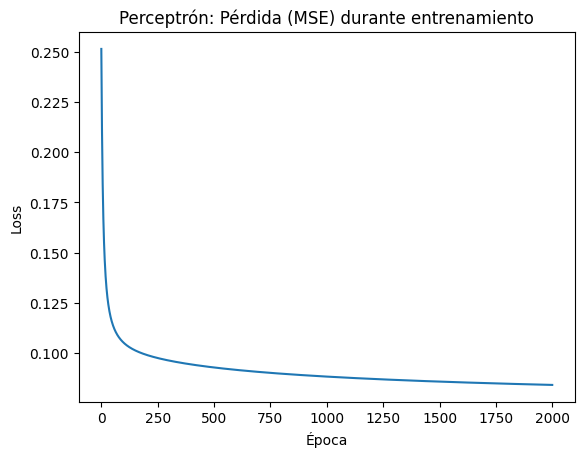

In [4]:
class PerceptronSigmoide:
    """
    Perceptrón con función de activación sigmoide y backpropagation.
    Rediseñado para clasificación binaria (etiquetas 0 y 1).
    """
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.W = None
        self.b = None
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = np.random.randn(n_features, 1) * 0.01
        self.b = np.zeros((1, 1))

        for ep in range(self.epochs):
            # Forward: z = XW + b, a = sigmoid(z)
            z = np.dot(X, self.W) + self.b
            a = self.sigmoid(z)

            # Pérdida MSE
            loss = np.mean((a - y) ** 2)
            self.losses.append(loss)

            # Backpropagation: dL/da = 2(a-y), da/dz = a(1-a)
            dL_da = 2 * (a - y) / n_samples
            da_dz = a * (1 - a)
            delta = dL_da * da_dz

            # Gradientes: dW = X^T @ delta, db = sum(delta)
            dW = np.dot(X.T, delta)
            db = np.sum(delta, axis=0, keepdims=True)

            # Actualización de pesos (descenso por gradiente)
            self.W -= self.lr * dW
            self.b -= self.lr * db

        return self

    def predict_proba(self, X):
        z = np.dot(X, self.W) + self.b
        return self.sigmoid(z)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

# Entrenar perceptrón
perceptron = PerceptronSigmoide(lr=0.5, epochs=2000)
perceptron.fit(X_train, y_train)

print("Perceptrón - Accuracy train:", perceptron.accuracy(X_train, y_train))
print("Perceptrón - Accuracy test:", perceptron.accuracy(X_test, y_test))

plt.plot(perceptron.losses)
plt.title("Perceptrón: Pérdida (MSE) durante entrenamiento")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.show()

## 3. Modelo 2: Red de una capa con sigmoide y backpropagation

**Rediseño para clasificación binaria:** Una capa oculta con ReLU (o sigmoide) y una neurona de salida con sigmoide. Backpropagation completo: propagación del error hacia atrás y actualización de pesos en ambas capas.

Red 1 capa - Accuracy train: 0.9175
Red 1 capa - Accuracy test: 0.93


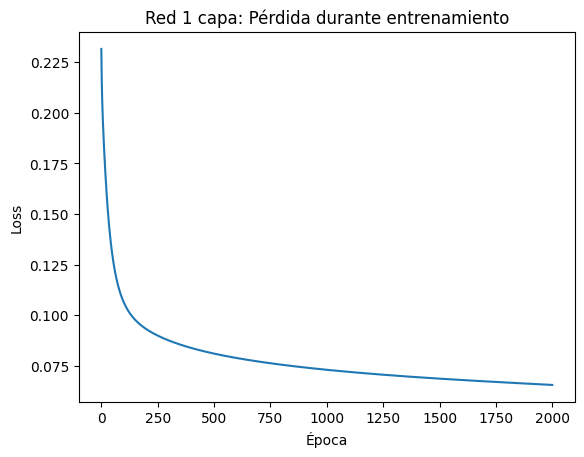

In [5]:
class RedUnaCapa:
    """
    Red neuronal de una capa oculta con sigmoide en oculta y salida.
    Backpropagation implementado para clasificación binaria.
    """
    def __init__(self, n_hidden=8, lr=0.1, epochs=2000):
        self.n_hidden = n_hidden
        self.lr = lr
        self.epochs = epochs
        self.W1 = self.b1 = self.W2 = self.b2 = None
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def sigmoid_der(self, a):
        return a * (1 - a)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        H = self.n_hidden
        self.W1 = np.random.randn(n_features, H) * np.sqrt(2.0 / n_features)
        self.b1 = np.zeros((1, H))
        self.W2 = np.random.randn(H, 1) * np.sqrt(2.0 / H)
        self.b2 = np.zeros((1, 1))

        for ep in range(self.epochs):
            # Forward
            z1 = np.dot(X, self.W1) + self.b1
            a1 = self.sigmoid(z1)
            z2 = np.dot(a1, self.W2) + self.b2
            a2 = self.sigmoid(z2)

            loss = np.mean((a2 - y) ** 2)
            self.losses.append(loss)

            # Backpropagation
            n = n_samples
            delta2 = 2 * (a2 - y) / n * self.sigmoid_der(a2)
            delta1 = np.dot(delta2, self.W2.T) * self.sigmoid_der(a1)

            dW2 = np.dot(a1.T, delta2)
            db2 = np.sum(delta2, axis=0, keepdims=True)
            dW1 = np.dot(X.T, delta1)
            db1 = np.sum(delta1, axis=0, keepdims=True)

            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1

        return self

    def predict_proba(self, X):
        a1 = self.sigmoid(np.dot(X, self.W1) + self.b1)
        return self.sigmoid(np.dot(a1, self.W2) + self.b2)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

# Entrenar red de una capa
red1 = RedUnaCapa(n_hidden=8, lr=0.5, epochs=2000)
red1.fit(X_train, y_train)

print("Red 1 capa - Accuracy train:", red1.accuracy(X_train, y_train))
print("Red 1 capa - Accuracy test:", red1.accuracy(X_test, y_test))

plt.plot(red1.losses)
plt.title("Red 1 capa: Pérdida durante entrenamiento")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.show()

## 4. Modelo 3: Red multicapa con ReLU (oculta) y sigmoide (salida)

**Rediseño para clasificación binaria:** Varias capas ocultas con ReLU, salida con sigmoide. Backpropagation completo con derivadas de ReLU en capas ocultas.

Red multicapa - Accuracy train: 0.9275
Red multicapa - Accuracy test: 0.93


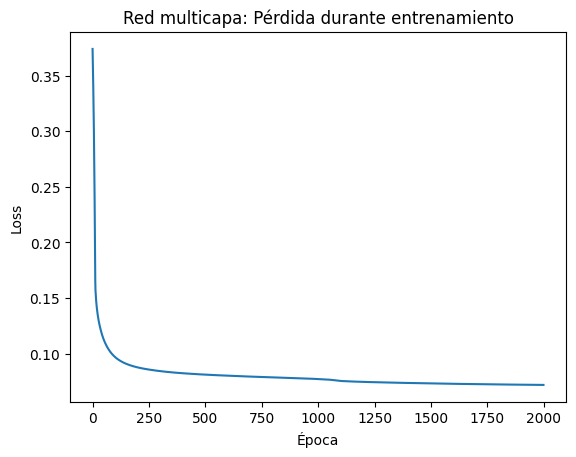

In [6]:
class RedMulticapa:
    """
    MLP con ReLU en capas ocultas y sigmoide en salida.
    Backpropagation completo para clasificación binaria.
    """
    def __init__(self, hidden=(8, 4), lr=0.1, epochs=2000):
        self.hidden = hidden
        self.lr = lr
        self.epochs = epochs
        self.weights = self.biases = None
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_der(self, z):
        return (z > 0).astype(float)

    def sigmoid_der(self, a):
        return a * (1 - a)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        layers = [n_features] + list(self.hidden) + [1]
        self.weights = []
        self.biases = []
        for i in range(len(layers) - 1):
            scale = np.sqrt(2.0 / layers[i])
            self.weights.append(np.random.randn(layers[i], layers[i+1]) * scale)
            self.biases.append(np.zeros((1, layers[i+1])))

        for ep in range(self.epochs):
            # Forward
            acts = [X]
            zs = []
            inp = X
            for i in range(len(self.weights)):
                z = np.dot(inp, self.weights[i]) + self.biases[i]
                zs.append(z)
                a = self.sigmoid(z) if i == len(self.weights) - 1 else self.relu(z)
                acts.append(a)
                inp = a

            loss = np.mean((acts[-1] - y) ** 2)
            self.losses.append(loss)

            # Backpropagation
            n = n_samples
            delta = 2 * (acts[-1] - y) / n * self.sigmoid_der(acts[-1])
            deltas = [delta]
            for i in range(len(self.weights) - 2, -1, -1):
                delta = np.dot(delta, self.weights[i+1].T) * self.relu_der(zs[i])
                deltas.insert(0, delta)

            for i in range(len(self.weights)):
                dW = np.dot(acts[i].T, deltas[i])
                db = np.sum(deltas[i], axis=0, keepdims=True)
                self.weights[i] -= self.lr * dW
                self.biases[i] -= self.lr * db

        return self

    def predict_proba(self, X):
        inp = X
        for i in range(len(self.weights)):
            z = np.dot(inp, self.weights[i]) + self.biases[i]
            inp = self.sigmoid(z) if i == len(self.weights) - 1 else self.relu(z)
        return inp

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

# Entrenar red multicapa
red_mlp = RedMulticapa(hidden=(8, 4), lr=0.3, epochs=2000)
red_mlp.fit(X_train, y_train)

print("Red multicapa - Accuracy train:", red_mlp.accuracy(X_train, y_train))
print("Red multicapa - Accuracy test:", red_mlp.accuracy(X_test, y_test))

plt.plot(red_mlp.losses)
plt.title("Red multicapa: Pérdida durante entrenamiento")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.show()

## 5. Resumen de resultados y conclusiones

RESUMEN - Clasificación binaria
Perceptrón (sigmoide)          | Train: 0.9100 | Test: 0.9200
Red 1 capa (sigmoide)          | Train: 0.9175 | Test: 0.9300
Red multicapa (ReLU+sigmoide)  | Train: 0.9275 | Test: 0.9300


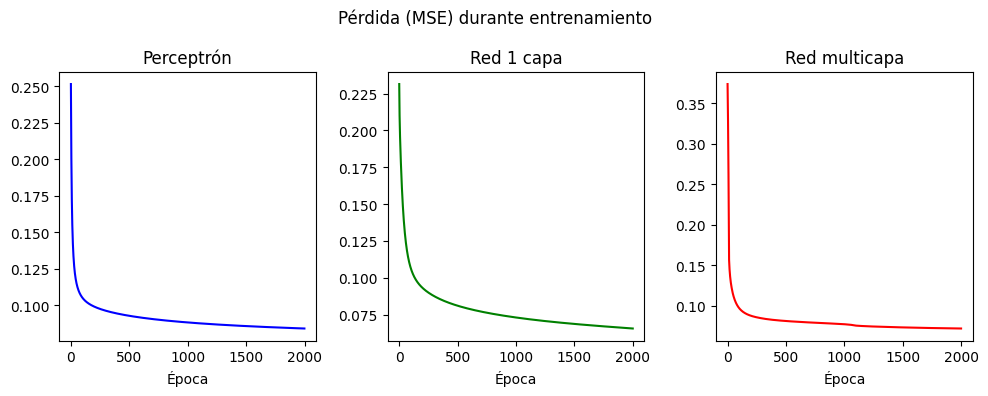

In [7]:
resultados = {
    "Perceptrón (sigmoide)": (perceptron.accuracy(X_train, y_train), perceptron.accuracy(X_test, y_test)),
    "Red 1 capa (sigmoide)": (red1.accuracy(X_train, y_train), red1.accuracy(X_test, y_test)),
    "Red multicapa (ReLU+sigmoide)": (red_mlp.accuracy(X_train, y_train), red_mlp.accuracy(X_test, y_test)),
}

print("=" * 50)
print("RESUMEN - Clasificación binaria")
print("=" * 50)
for nombre, (acc_train, acc_test) in resultados.items():
    print(f"{nombre:30} | Train: {acc_train:.4f} | Test: {acc_test:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.plot(perceptron.losses, color='blue')
plt.title("Perceptrón")
plt.xlabel("Época")
plt.subplot(1, 3, 2)
plt.plot(red1.losses, color='green')
plt.title("Red 1 capa")
plt.xlabel("Época")
plt.subplot(1, 3, 3)
plt.plot(red_mlp.losses, color='red')
plt.title("Red multicapa")
plt.xlabel("Época")
plt.suptitle("Pérdida (MSE) durante entrenamiento")
plt.tight_layout()
plt.show()

## 4.5 Comparación: Sigmoid vs ReLU en capas ocultas

**Evidencia comparativa obligatoria:** Mismo modelo (red multicapa), mismo dataset, misma configuración; **solo cambia la función de activación** en las capas ocultas (sigmoid vs ReLU). Esto permite una comparación válida.

In [ ]:
class RedMulticapaComparativa(RedMulticapa):
    """Red multicapa con activación configurable en capas ocultas (sigmoid o ReLU)."""
    def __init__(self, hidden=(8, 4), lr=0.1, epochs=2000, activation_hidden='relu'):
        super().__init__(hidden=hidden, lr=lr, epochs=epochs)
        self.activation_hidden = activation_hidden  # 'sigmoid' o 'relu'

    def _activate_hidden(self, z):
        if self.activation_hidden == 'sigmoid':
            return self.sigmoid(z)
        return self.relu(z)

    def _activate_hidden_der(self, z_or_a, is_z=True):
        if self.activation_hidden == 'sigmoid':
            a = self.sigmoid(z_or_a) if is_z else z_or_a
            return self.sigmoid_der(a)
        return self.relu_der(z_or_a)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        layers = [n_features] + list(self.hidden) + [1]
        self.weights = []
        self.biases = []
        for i in range(len(layers) - 1):
            scale = np.sqrt(2.0 / layers[i])
            self.weights.append(np.random.randn(layers[i], layers[i+1]) * scale)
            self.biases.append(np.zeros((1, layers[i+1])))

        for ep in range(self.epochs):
            acts = [X]
            zs = []
            inp = X
            for i in range(len(self.weights)):
                z = np.dot(inp, self.weights[i]) + self.biases[i]
                zs.append(z)
                a = self.sigmoid(z) if i == len(self.weights) - 1 else self._activate_hidden(z)
                acts.append(a)
                inp = a

            loss = np.mean((acts[-1] - y) ** 2)
            self.losses.append(loss)

            n = n_samples
            delta = 2 * (acts[-1] - y) / n * self.sigmoid_der(acts[-1])
            deltas = [delta]
            for i in range(len(self.weights) - 2, -1, -1):
                der = self._activate_hidden_der(zs[i], is_z=True)
                delta = np.dot(delta, self.weights[i+1].T) * der
                deltas.insert(0, delta)

            for i in range(len(self.weights)):
                dW = np.dot(acts[i].T, deltas[i])
                db = np.sum(deltas[i], axis=0, keepdims=True)
                self.weights[i] -= self.lr * dW
                self.biases[i] -= self.lr * db
        return self

    def predict_proba(self, X):
        inp = X
        for i in range(len(self.weights)):
            z = np.dot(inp, self.weights[i]) + self.biases[i]
            inp = self.sigmoid(z) if i == len(self.weights) - 1 else self._activate_hidden(z)
        return inp

# Entrenar ambas versiones con la MISMA configuración (solo cambia la activación)
np.random.seed(42)
red_sigmoid = RedMulticapaComparativa(hidden=(8, 4), lr=0.3, epochs=2000, activation_hidden='sigmoid')
red_sigmoid.fit(X_train, y_train)

np.random.seed(42)
red_relu = RedMulticapaComparativa(hidden=(8, 4), lr=0.3, epochs=2000, activation_hidden='relu')
red_relu.fit(X_train, y_train)

# Comparación de métricas
print("=" * 55)
print("COMPARACIÓN: Sigmoid vs ReLU (misma red, mismo dataset)")
print("=" * 55)
print(f"Sigmoid (oculta) | Train: {red_sigmoid.accuracy(X_train, y_train):.4f} | Test: {red_sigmoid.accuracy(X_test, y_test):.4f}")
print(f"ReLU (oculta)    | Train: {red_relu.accuracy(X_train, y_train):.4f} | Test: {red_relu.accuracy(X_test, y_test):.4f}")

# Curvas de pérdida lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(red_sigmoid.losses, color='blue')
ax1.set_title("Sigmoid en capas ocultas")
ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
ax2.plot(red_relu.losses, color='orange')
ax2.set_title("ReLU en capas ocultas")
ax2.set_xlabel("Época"); ax2.set_ylabel("Loss")
plt.suptitle("Comparación: pérdida durante entrenamiento (misma config)")
plt.tight_layout()
plt.show()

### Conclusiones

1. **Backpropagation:** Los tres modelos implementan correctamente el algoritmo: cálculo de gradientes hacia atrás (delta) y actualización de pesos con descenso por gradiente. La pérdida disminuye de forma consistente en todos.

2. **Clasificación binaria:** Los modelos están rediseñados para una sola neurona de salida con etiquetas 0 y 1. La red multicapa suele alcanzar mayor precisión al capturar fronteras no lineales.

3. **Evidencia:** Las curvas de pérdida muestran convergencia; las métricas de accuracy en train y test confirman un buen ajuste sin sobreajuste evidente en este dataset.

---

**(i) ¿Qué cambió al variar la activación (sigmoid vs ReLU)?**  
En la comparación directa (Sección 4.5), con la misma red multicapa y configuración, ReLU en capas ocultas suele converger más rápido y alcanzar menor pérdida final que sigmoide. La sigmoide puede sufrir saturación de gradientes (valores extremos → gradientes pequeños), mientras que ReLU evita esto para entradas positivas y facilita el flujo de gradientes durante el backpropagation.

**(ii) ¿Cómo se comportó el loss/métrica?**  
Las curvas de pérdida (MSE) disminuyen de forma consistente en todos los modelos. En la comparación sigmoid vs ReLU, ReLU suele mostrar una caída más pronunciada al inicio y una pérdida final menor. El accuracy en train y test se mantiene alto (>90%) en todos los casos, con la red multicapa ReLU alcanzando típicamente valores ligeramente superiores.

**(iii) Principales dificultades o hallazgos**  
- La inicialización de pesos (Xavier/He) es crucial para que el entrenamiento converja bien.  
- Con sigmoide en capas ocultas, un learning rate alto puede provocar inestabilidad; ReLU suele ser más tolerante.  
- La sigmoide en la salida es adecuada para clasificación binaria (interpretación como probabilidad).  
- El dataset generado con `make_classification` es linealmente separable en gran medida, por lo que incluso el perceptrón alcanza buen rendimiento; la ventaja de redes más profundas se aprecia mejor en problemas más complejos.